In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer # apply different preprocessing steps to different columns
from sklearn.pipeline import Pipeline



from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_parquet('/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/data_ml.parquet')

train_df = pd.read_parquet("classification_ring/data/processed/train.parquet")
val_df = pd.read_parquet("classification_ring/data/processed/val.parquet") # dont load the test set yet, we will use it only at the very end to evaluate the final classifier


train_df.head()

print(train_df.shape)
train_df.head()

(999083, 38)


,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,2i49,A,444,,L,H,0.073,-0.990,-0.759,-1.019,...,1.648,5.0,F,0,0,0,0,0,0,1
1,2i49,A,157,,A,-,0.000,-1.132,2.664,-0.591,...,-0.078,1.0,B,1,0,0,0,0,0,1
2,2i49,A,81,,G,T,0.357,1.342,0.258,-0.384,...,1.648,17.0,R,1,0,0,0,0,0,0
3,2i49,A,172,,A,G,0.009,-1.754,0.040,-0.591,...,0.816,13.0,N,1,0,0,0,0,0,0
4,2i49,A,316,,G,S,0.310,-0.955,2.750,-0.384,...,0.933,17.0,R,1,0,0,0,0,0,1


In [13]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    #'t_3di_state' # we dont need it twice, we can use the letter instead
]

cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

feature_cols = num_features + cat_features

print("Label distribution:")
print(train_df[label_cols].sum().sort_values(ascending=False))




X_train = train_df[feature_cols].copy()
Y_train = train_df[label_cols].copy()

X_val = val_df[feature_cols].copy()
Y_val = val_df[label_cols].copy()

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

Label distribution:
HBOND        727034
VDW          506568
PIPISTACK     26619
IONIC         24650
PICATION       6085
SSBOND         1345
PIHBOND        1322
dtype: int64
X_train shape: (999083, 21)
Y_train shape: (999083, 7)


In [14]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical:impute with most frequent,then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' ensures that if a category appears in the test set that wasn't seen in the training set, it won't cause an error. Instead, it will be ignored and encoded as all zeros.
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

rf = MultiOutputClassifier(
    RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf)
    ],
    verbose = True # prints some logging, which might be useful to see the progress of the training
)

print("Pipeline built successfully")

Pipeline built successfully


#### Train and save model to file

In [15]:
train_model_bool = False
save_model_bool = False



if train_model_bool:
    print("Training")
    pipeline.fit(X_train, Y_train)
    print("Training complete!")
    
    if save_model_bool:
        # Saving model to file with pickle
        import pickle
        model_folder = "classification_ring/models/random_forest/"
        os.makedirs(os.path.dirname(model_folder), exist_ok=True)
        model_path = os.path.join(model_folder, "random_forest_model.pkl")
        with open(model_path, "wb") as f:
            pickle.dump(pipeline, f)
        print(f"Model saved to {model_path}")

#### Load model (if was already trained)

In [20]:
load_model_bool = True

if load_model_bool:
    import pickle
    model_path = "classification_ring/models/random_forest/random_forest_model.pkl"
    with open(model_path, "rb") as f:
        rf = pickle.load(f)
    print(f"Model loaded from {model_path}")

Model loaded from classification_ring/models/random_forest/random_forest_model.pkl


# Evaluation on the validation set


Suggested metrics: 

- MCC (*), 
- BA (*) (Balanced Accuracy), 
- Average Precision (**) (area under the Precision-Recall curve)
- AUC ROC (**) (area under the Receiver-Operating Characteristic)


(*): depends on prediction threshold, (**): global metric, just depends on the scores.

In [6]:
def get_positive_class_scores(model, X):
    """
    Return an array of shape (n_samples, n_classes)
    containing P(class = 1) for each class.
    """
    y_proba = model.predict_proba(X)

    # Multi-label case: list of arrays, one per class
    if isinstance(y_proba, list):
        y_scores = np.column_stack([proba[:, 1] for proba in y_proba])

    # Binary/multiclass single-output case
    else:
        y_scores = y_proba[:, 1]

    return y_scores



# Compute all metrics and stores in dataframes
recompute_metrics_bool = True

if recompute_metrics_bool:


    target_names = label_cols

    # ------------------------------------------------------------
    # 1. Get predicted probabilities
    # ------------------------------------------------------------

    y_scores = get_positive_class_scores(rf, X_val) # <----- model = Random Forest Classifier

    thresholds = np.arange(0.00, 1.01, 0.01)

    threshold_results = []
    curve_results = []

    # ------------------------------------------------------------
    # 2. Compute metrics class by class
    # ------------------------------------------------------------

    for class_idx, class_name in enumerate(target_names):

        y_true = Y_val.iloc[:, class_idx].values
        y_score = y_scores[:, class_idx]

        # --------------------------------------------------------
        # Threshold-dependent metrics
        # --------------------------------------------------------

        for threshold in thresholds:

            y_pred = (y_score >= threshold).astype(int)

            threshold_results.append({
                "class": class_name,
                "threshold": threshold,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
            })

        # --------------------------------------------------------
        # Threshold-independent curve data
        # --------------------------------------------------------

        precision, recall, pr_thresholds = precision_recall_curve(
            y_true,
            y_score
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_score
        )

        ap = average_precision_score(
            y_true,
            y_score
        )

        auc = roc_auc_score(
            y_true,
            y_score
        )

        curve_results.append({
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "average_precision": ap,
            "ROC_AUC": auc
        })

    # ------------------------------------------------------------
    # 3. Convert to DataFrames
    # ------------------------------------------------------------

    threshold_results_df = pd.DataFrame(threshold_results)
    curve_results_df = pd.DataFrame(curve_results)

    # ------------------------------------------------------------
    # 4. Save to files
    # ------------------------------------------------------------

    threshold_results_df.to_parquet("classification_ring/models/random_forest/threshold_results.parquet", index=False)
    curve_results_df.to_parquet("classification_ring/models/random_forest/curve_results.parquet", index=False)

---

#### Analysis of validation scores

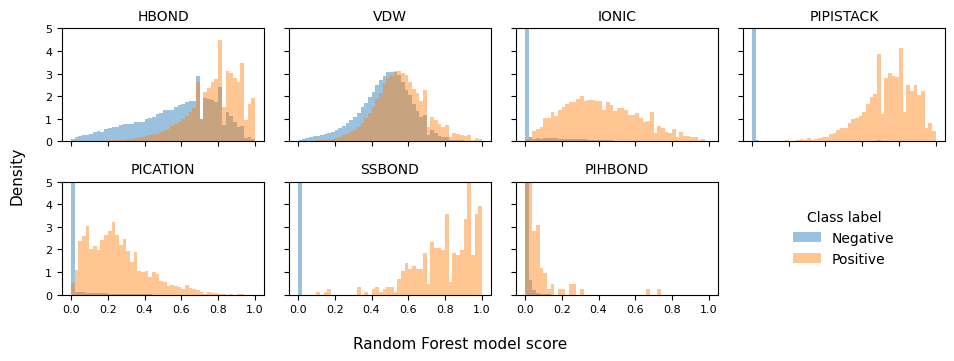

In [7]:

# ---- Report-quality score-distribution figure ----

n_classes = len(target_names)
n_cols = len(target_names) // 2 + 1
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 4.2),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

y_scores = get_positive_class_scores(rf, X_val)

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    y_true_class = (
        Y_val.iloc[:, class_idx]
        if hasattr(Y_val, "iloc")
        else Y_val[:, class_idx]
    )

    scores = y_scores[:, class_idx]

    positives = scores[y_true_class == 1]
    negatives = scores[y_true_class == 0]

    poscounts, posbins = np.histogram(
        positives,
        bins=50,
        range=(0, 1),
        density=True
    )

    negcounts, negbins = np.histogram(
        negatives,
        bins=50,
        range=(0, 1),
        density=True
    )

    ax.bar(
        negbins[:-1],
        negcounts,
        width=np.diff(negbins),
        label="Negative",
        alpha=0.45,
        align="edge"
    )

    ax.bar(
        posbins[:-1],
        poscounts,
        width=np.diff(posbins),
        label="Positive",
        alpha=0.45,
        align="edge"
    )

    ax.set_title(class_name, fontsize=10)
    ax.set_ylim(0, 5)
    ax.tick_params(axis="both", labelsize=8)


# ---- Put legend in the unused bottom-right axis ----

legend_ax = axes[-1]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

legend_ax.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
    fontsize=10,
    title="Class label",
    title_fontsize=10
)


# ---- Shared labels and title ----

#fig.suptitle(
#    "Score distribution on the validation set",
#    fontsize=14,
#    y=0.98
#)

fig.supxlabel(
    "Random Forest model score",
    fontsize=11,
    y=0.08
)

fig.supylabel(
    "Density",
    fontsize=11,
    x=0.05
)


# ---- Layout and save ----

fig.tight_layout(rect=[0.04, 0.06, 1.00, 0.93])

fig.savefig(
    "report_figures/random_forest_scores.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()

---

#### Feature importance

In [26]:
# Extract fitted parts
preprocessor = rf.named_steps["preprocessor"]
classifier = rf.named_steps["classifier"]

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# One LogisticRegression model per class
estimators = classifier.estimators_

# Store coefficients class by class
coef_tables = {}

for class_idx, class_name in enumerate(target_names):
    model = estimators[class_idx]

    coefs = model.feature_importances_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "importance": coefs,
    }).sort_values("importance", ascending=False)

    coef_tables[class_name] = coef_df

display(coef_tables["SSBOND"].head(15))

/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/mini

,feature,importance
6,num__s_a4,0.193276
12,num__t_a1,0.165600
3,num__s_a1,0.130259
15,num__t_a4,0.125336
13,num__t_a2,0.084325
4,num__s_a2,0.079996
5,num__s_a3,0.064962
14,num__t_a3,0.054442
7,num__s_a5,0.051248
16,num__t_a5,0.028870


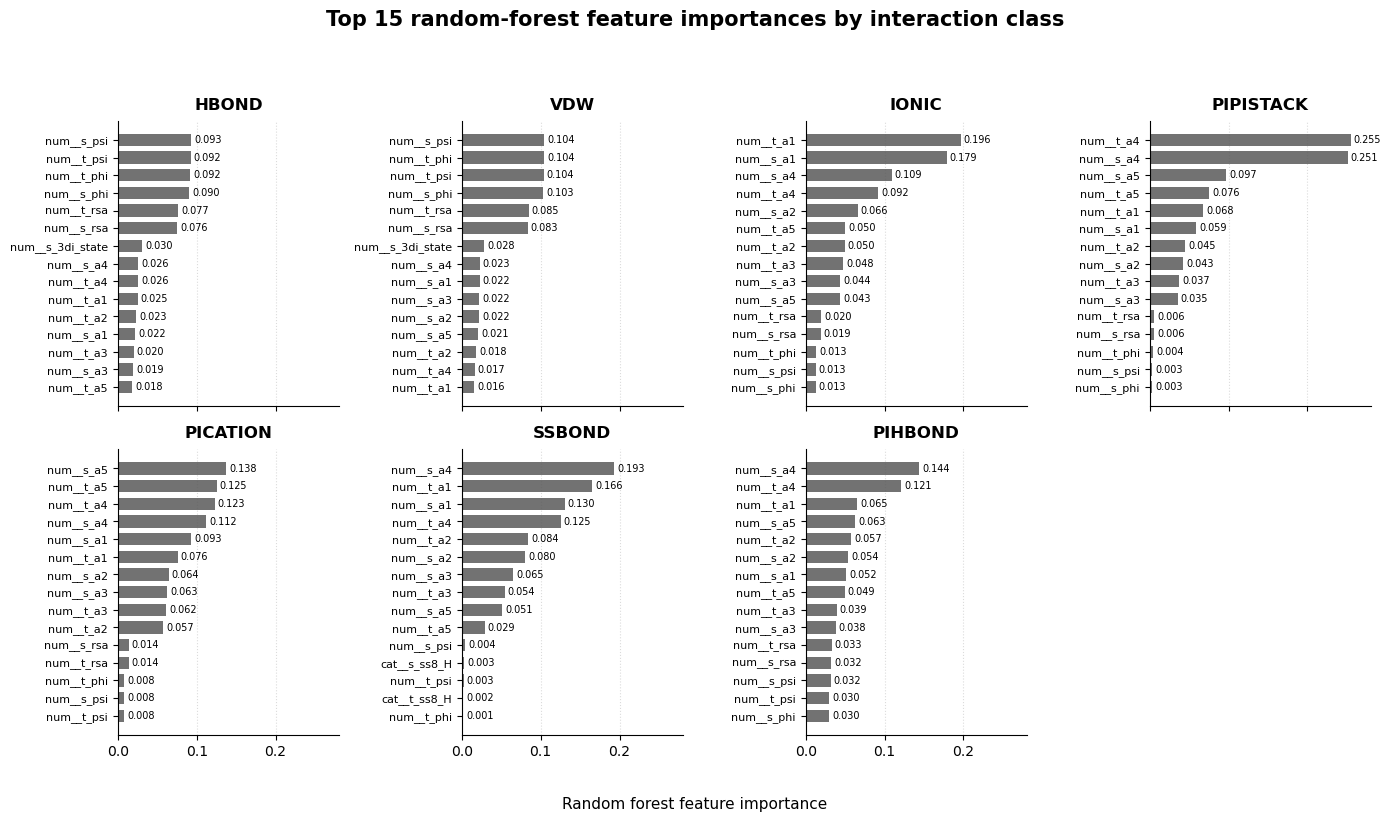

In [30]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

top_n = 15

coef_plot_tables = {}

# ------------------------------------------------------------
# 1. Select top features per class
# ------------------------------------------------------------

for class_name, coef_df in coef_tables.items():

    plot_df = (
        coef_df
        .sort_values("importance", ascending=False)
        .head(top_n)
        .sort_values("importance", ascending=True)
        .copy()
    )

    coef_plot_tables[class_name] = plot_df


# ------------------------------------------------------------
# 2. Shared x-axis limits
# ------------------------------------------------------------

max_importance = max(
    df["importance"].max()
    for df in coef_plot_tables.values()
)

xlim = (0, 1.10 * max_importance)


# ------------------------------------------------------------
# 3. Figure layout
# ------------------------------------------------------------

n_classes = len(coef_plot_tables)
n_cols = 4
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.2 * n_rows),
    sharex=True
)

axes = np.array(axes).reshape(-1)


# ------------------------------------------------------------
# 4. Plot class-specific feature importances
# ------------------------------------------------------------

for ax, (class_name, plot_df) in zip(axes, coef_plot_tables.items()):

    y_pos = np.arange(len(plot_df))

    ax.barh(
        y_pos,
        plot_df["importance"],
        color="0.35",
        alpha=0.85,
        height=0.7
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["feature"], fontsize=8)

    ax.set_title(
        class_name,
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    ax.set_xlim(xlim)

    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.8,
        alpha=0.45
    )

    ax.set_axisbelow(True)

    # Cleaner axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Optional: annotate importance values
    for y, value in enumerate(plot_df["importance"]):
        ax.text(
            value + 0.015 * max_importance,
            y,
            f"{value:.3f}",
            va="center",
            fontsize=7
        )


# ------------------------------------------------------------
# 5. Remove unused axes
# ------------------------------------------------------------

for ax in axes[len(coef_plot_tables):]:
    ax.axis("off")


# ------------------------------------------------------------
# 6. Global labels and title
# ------------------------------------------------------------

fig.supxlabel(
    "Random forest feature importance",
    fontsize=11,
    y=0.04
)

fig.suptitle(
    f"Top {top_n} random-forest feature importances by interaction class",
    fontsize=15,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig(
    "report_figures/random_forest_feature_importance_by_class.pdf",
    bbox_inches="tight"
)

plt.show()

#### Inspection of false positives

In [11]:
label_prevalence = Y_val.mean().sort_values(ascending=False)

prevalence_rows = {"baseline": label_prevalence}
false_positive_counts = {}

Y_pred_tuned_df = pd.DataFrame(
    Y_pred_tuned,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(label_cols):
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_tuned_df.iloc[:, class_idx] == 1)
    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue
    false_positives_no_self = false_positives.drop(columns=[class_name])


    fp_label_prevalence = false_positives_no_self.mean()
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

fp_prevalence_df = pd.DataFrame(prevalence_rows).T
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")

display(fp_prevalence_df)
print(false_positive_counts)


,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.727294,0.022955,0.006277,0.000888,0.024530,0.001809,0.506566
FP_HBOND,NaN,0.009083,0.017206,0.002516,0.019508,0.000490,0.974906
FP_VDW,0.968201,0.024522,0.006779,0.000812,0.029070,0.001692,NaN
FP_IONIC,0.842739,NaN,0.000000,0.000000,0.000000,0.000000,0.504149
FP_PIPISTACK,0.605735,0.000000,0.000000,0.000000,NaN,0.000000,0.567332
FP_PICATION,0.613757,0.000000,NaN,0.001323,0.000000,0.000000,0.618386
FP_SSBOND,0.480000,0.000000,0.000000,0.000000,0.000000,NaN,0.706667
FP_PIHBOND,0.532710,0.000000,0.028037,NaN,0.214953,0.000000,0.546729


HBOND         46903
VDW          102235
IONIC          4820
PIPISTACK      1953
PICATION       1512
SSBOND           75
PIHBOND         214
Name: n_false_positives, dtype: int64


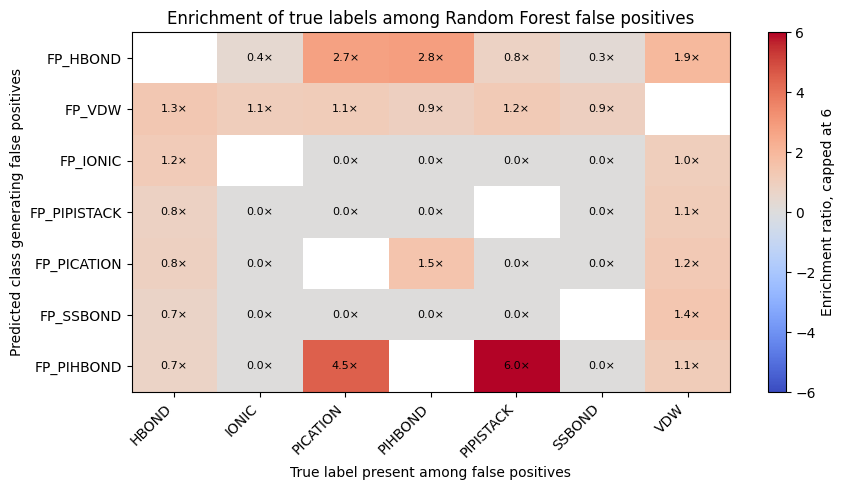

In [12]:
baseline = fp_prevalence_df.loc["baseline"]
fp_rows = fp_prevalence_df.drop(index="baseline")

enrichment_df = fp_rows.divide(baseline, axis=1)

plot_df = enrichment_df.clip(upper=6)

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(plot_df, aspect="auto", cmap="coolwarm", norm=norm)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among Random Forest false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


---

# Predict with constraints and save metrics to file

In [ ]:
def predict_with_constraints(pipeline, X, X_names, threshold=0.5):

    label_cols = [
        'HBOND', 'VDW', 'IONIC', 'PIPISTACK',
        'PICATION', 'SSBOND', 'PIHBOND'
    ]

    # ------------------------------------------------------------
    # 1. Get predicted probabilities
    # ------------------------------------------------------------

    y_proba = pipeline.predict_proba(X)

    proba_df = pd.DataFrame(
        np.column_stack([
            y_proba[i][:, 1] for i in range(len(label_cols))
        ]),
        columns=label_cols,
        index=X.index
    )

    # ------------------------------------------------------------
    # 2. Get residue names, assuming one-letter amino acid codes
    # ------------------------------------------------------------

    s_resn = X_names["s_resn"].str.upper()
    t_resn = X_names["t_resn"].str.upper()

    # ------------------------------------------------------------
    # 3. Define residue groups using one-letter codes
    # ------------------------------------------------------------

    acidic = {"D", "E"}        # Aspartate, Glutamate
    basic = {"K", "R", "H"}   # Lysine, Arginine, Histidine
    aromatic = {"F", "Y", "W", "H"}  # Phenylalanine, Tyrosine, Tryptophan, Histidine
    cysteine = {"C"}          # Cysteine

    # ------------------------------------------------------------
    # 4. Define biological feasibility masks
    # ------------------------------------------------------------

    ionic_possible = (
        (s_resn.isin(acidic) & t_resn.isin(basic)) |
        (t_resn.isin(acidic) & s_resn.isin(basic))
    )

    pipistack_possible = (
        s_resn.isin(aromatic) &
        t_resn.isin(aromatic)
    )

    pication_possible = (
        (s_resn.isin(aromatic) & t_resn.isin(basic)) |
        (t_resn.isin(aromatic) & s_resn.isin(basic))
    )

    ssbond_possible = (
        s_resn.isin(cysteine) &
        t_resn.isin(cysteine)
    )

    pihbond_possible = (
        s_resn.isin(aromatic) |
        t_resn.isin(aromatic)
    )

    # ------------------------------------------------------------
    # 5. Apply constraints
    # ------------------------------------------------------------

    proba_constrained_df = proba_df.copy()

    proba_constrained_df.loc[~ionic_possible, "IONIC"] = 0.0
    proba_constrained_df.loc[~pipistack_possible, "PIPISTACK"] = 0.0
    proba_constrained_df.loc[~pication_possible, "PICATION"] = 0.0
    proba_constrained_df.loc[~ssbond_possible, "SSBOND"] = 0.0
    proba_constrained_df.loc[~pihbond_possible, "PIHBOND"] = 0.0

    # ------------------------------------------------------------
    # 6. Threshold constrained probabilities
    # ------------------------------------------------------------

    y_pred = (
        proba_constrained_df > threshold
    ).astype(int)

    return y_pred, proba_constrained_df

In [ ]:
# Compute all metrics and stores in dataframes
recompute_metrics_bool = True

if recompute_metrics_bool:
    target_names = label_cols
    # ------------------------------------------------------------
    # 1. Get predicted probabilities
    # ------------------------------------------------------------
    X_val_names = val_df[pair_cols].copy()  # Extract the pair columns for residue names
    y_pred, proba_constrained_df = predict_with_constraints(rf, X_val, X_val_names, threshold=0.5)# <----- model = Random Forest Classifier
    y_scores = proba_constrained_df.values

    thresholds = np.arange(0.00, 1.01, 0.01)
    threshold_results = []
    curve_results = []
    # ------------------------------------------------------------
    # 2. Compute metrics class by class
    # ------------------------------------------------------------

    for class_idx, class_name in enumerate(target_names):

        y_true = Y_val.iloc[:, class_idx].values
        y_score = y_scores[:, class_idx]

        # --------------------------------------------------------
        # Threshold-dependent metrics
        # --------------------------------------------------------
        for threshold in thresholds:

            y_pred = (y_score >= threshold).astype(int)

            threshold_results.append({
                "class": class_name,
                "threshold": threshold,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
            })

        # --------------------------------------------------------
        # Threshold-independent curve data
        # --------------------------------------------------------
        precision, recall, pr_thresholds = precision_recall_curve(
            y_true,
            y_score
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_score
        )

        ap = average_precision_score(
            y_true,
            y_score
        )

        auc = roc_auc_score(
            y_true,
            y_score
        )

        curve_results.append({
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "average_precision": ap,
            "ROC_AUC": auc
        })

    # ------------------------------------------------------------
    # 3. Convert to DataFrames
    # ------------------------------------------------------------
    threshold_results_df = pd.DataFrame(threshold_results)
    curve_results_df = pd.DataFrame(curve_results)

    # ------------------------------------------------------------
    # 4. Save to files
    # ------------------------------------------------------------
    threshold_results_df.to_parquet("classification_ring/models/random_forest/postprocessed_threshold_results.parquet", index=False)
    curve_results_df.to_parquet("classification_ring/models/random_forest/postprocessed_curve_results.parquet", index=False)

/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/miniconda3/envs/SBenv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/miriamzara/mini